## Bài tập 1 — Phân lớp (doanh số đồ chơi)

- Install and import libraries

In [4]:
%pip install -q graphviz

Note: you may need to restart the kernel to use updated packages.


In [1]:
import math
from collections import Counter

from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

- Import data

In [7]:
data = [
{"Loai":"Dieu khien","Mau":3,"Size":"Nho","ChatLieu":"Nhua PP","Label":"Cao"},
{"Loai":"Xep hinh","Mau":5,"Size":"Vua","ChatLieu":"Cao su","Label":"Thap"},
{"Loai":"Xep hinh","Mau":7,"Size":"To","ChatLieu":"Nhua PP","Label":"Thap"},
{"Loai":"Dieu khien","Mau":5,"Size":"Nho","ChatLieu":"Cao su","Label":"Thap"},
{"Loai":"Bup be","Mau":3,"Size":"Vua","ChatLieu":"Nhua PP","Label":"Thap"},
{"Loai":"Dieu khien","Mau":5,"Size":"Vua","ChatLieu":"Nhua PP","Label":"Cao"},
{"Loai":"Bup be","Mau":5,"Size":"To","ChatLieu":"Nhua PP","Label":"Cao"},
{"Loai":"Dieu khien","Mau":7,"Size":"Vua","ChatLieu":"Cao su","Label":"Thap"},
{"Loai":"Xep hinh","Mau":7,"Size":"To","ChatLieu":"Cao su","Label":"Cao"},
{"Loai":"Xep hinh","Mau":3,"Size":"To","ChatLieu":"Nhua PP","Label":"Thap"},
{"Loai":"Bup be","Mau":3,"Size":"Nho","ChatLieu":"Cao su","Label":"Thap"},
{"Loai":"Xep hinh","Mau":3,"Size":"Nho","ChatLieu":"Nhua PP","Label":"Cao"},
{"Loai":"Dieu khien","Mau":5,"Size":"To","ChatLieu":"Cao su","Label":"Thap"},
{"Loai":"Bup be","Mau":5,"Size":"Vua","ChatLieu":"Nhua PP","Label":"Cao"},
{"Loai":"Bup be","Mau":7,"Size":"To","ChatLieu":"Nhua PP","Label":"Cao"},
]

df = pd.DataFrame(data)
display(df)


,Loai,Mau,Size,ChatLieu,Label
0,Dieu khien,3,Nho,Nhua PP,Cao
1,Xep hinh,5,Vua,Cao su,Thap
2,Xep hinh,7,To,Nhua PP,Thap
3,Dieu khien,5,Nho,Cao su,Thap
4,Bup be,3,Vua,Nhua PP,Thap
5,Dieu khien,5,Vua,Nhua PP,Cao
6,Bup be,5,To,Nhua PP,Cao
7,Dieu khien,7,Vua,Cao su,Thap
8,Xep hinh,7,To,Cao su,Cao
9,Xep hinh,3,To,Nhua PP,Thap


**Câu 1: Tính giá trị độ lợi thông tin (information gain) của các thuộc tính và vẽ cây quyết
định theo thuật toán ID3 cho dữ liệu trên.**

- Tính entropy

In [17]:
def entropy(labels):
    counter = Counter(labels)
    total = len(labels)
    return -sum((c/total)*math.log2(c/total) for c in counter.values())

entropy([d["Label"] for d in data])

0.9967916319816366

- Tính information gain

In [22]:
def info_gain(data, attr):
    total_entropy = entropy([d["Label"] for d in data])
    
    values = set(d[attr] for d in data)
    weighted_entropy = 0
    
    for v in values:
        subset = [d for d in data if d[attr] == v]
        weighted_entropy += (len(subset)/len(data)) * entropy([d["Label"] for d in subset])
    
    return total_entropy - weighted_entropy

- Tính IG cho từng thuộc tính

In [23]:
for attr in ["Loai", "Mau", "Size", "ChatLieu"]:
    print(attr, ":", round(info_gain(data, attr), 4))

Loai : 0.0258
Mau : 0.0065
Size : 0.0065
ChatLieu : 0.1858


- Vẽ cây

In [25]:
def majority_class(data):
    labels = [d["Label"] for d in data]
    return Counter(labels).most_common(1)[0][0]

def build_tree(data, attributes):
    labels = [d["Label"] for d in data]

    # Nếu cùng 1 class
    if len(set(labels)) == 1:
        return labels[0]

    # Nếu hết thuộc tính
    if not attributes:
        return majority_class(data)

    # chọn best attr
    gains = {attr: info_gain(data, attr) for attr in attributes}
    best_attr = max(gains, key=gains.get)

    tree = {best_attr: {}}

    for v in set(d[best_attr] for d in data):
        subset = [d for d in data if d[best_attr] == v]

        if not subset:
            tree[best_attr][v] = majority_class(data)
        else:
            new_attrs = [a for a in attributes if a != best_attr]
            tree[best_attr][v] = build_tree(subset, new_attrs)

    return tree

tree = build_tree(data, ["Loai", "Mau", "Size", "ChatLieu"])
tree

{'ChatLieu': {'Nhua PP': {'Loai': {'Dieu khien': 'Cao',
    'Bup be': {'Mau': {3: 'Thap', 5: 'Cao', 7: 'Cao'}},
    'Xep hinh': {'Size': {'Nho': 'Cao', 'To': 'Thap'}}}},
  'Cao su': {'Loai': {'Dieu khien': 'Thap',
    'Bup be': 'Thap',
    'Xep hinh': {'Mau': {5: 'Thap', 7: 'Cao'}}}}}}

**Câu 2: Tính giá trị chỉ số Gini (gini index) của các thuộc tính và vẽ cây quyết định theo thuật toán CART cho dữ liệu trên.**

- Gini

In [26]:
def gini(labels):
    from collections import Counter
    counter = Counter(labels)
    total = len(labels)
    return 1 - sum((c/total)**2 for c in counter.values())

def gini_split(data, attr):
    values = set(d[attr] for d in data)
    g = 0
    
    for v in values:
        subset = [d for d in data if d[attr] == v]
        g += (len(subset)/len(data)) * gini([d["Label"] for d in subset])
    
    return g

for attr in ["Loai", "Mau", "Size", "ChatLieu"]:
    print(attr, ":", round(gini_split(data, attr), 4))

Loai : 0.48
Mau : 0.4933
Size : 0.4933
ChatLieu : 0.3778


- Vẽ cây quyết định

In [27]:
def build_tree_gini(data, attributes):
    labels = [d["Label"] for d in data]

    # Nếu cùng 1 class
    if len(set(labels)) == 1:
        return labels[0]

    if not attributes:
        return Counter(labels).most_common(1)[0][0]

    # chọn attr có gini nhỏ nhất
    gini_values = {attr: gini_split(data, attr) for attr in attributes}
    best_attr = min(gini_values, key=gini_values.get)

    tree = {best_attr: {}}

    for v in set(d[best_attr] for d in data):
        subset = [d for d in data if d[best_attr] == v]

        if not subset:
            tree[best_attr][v] = Counter(labels).most_common(1)[0][0]
        else:
            new_attrs = [a for a in attributes if a != best_attr]
            tree[best_attr][v] = build_tree_gini(subset, new_attrs)

    return tree

tree_gini = build_tree_gini(data, ["Loai", "Mau", "Size", "ChatLieu"])
tree_gini

{'ChatLieu': {'Nhua PP': {'Loai': {'Dieu khien': 'Cao',
    'Bup be': {'Mau': {3: 'Thap', 5: 'Cao', 7: 'Cao'}},
    'Xep hinh': {'Size': {'Nho': 'Cao', 'To': 'Thap'}}}},
  'Cao su': {'Loai': {'Dieu khien': 'Thap',
    'Bup be': 'Thap',
    'Xep hinh': {'Mau': {5: 'Thap', 7: 'Cao'}}}}}}

**Câu 3: Sử dụng một trong hai cây quyết định ở trên để tiên đoán giá trị Doanh số bán của những sản phẩm**

- Dữ liệu bài 3

In [29]:
bai_3 = [
    {"Loai":"Bup be","Mau":3,"Size":"To","ChatLieu":"Cao su"},
    {"Loai":"Xep hinh","Mau":5,"Size":"To","ChatLieu":"Nhua PP"},
    {"Loai":"Dieu khien","Mau":3,"Size":"Vua","ChatLieu":"Cao su"},
]

In [30]:
def predict(tree, sample):
    if type(tree) != dict:
        return tree
    
    attr = list(tree.keys())[0]
    value = sample[attr]
    
    if value in tree[attr]:
        return predict(tree[attr][value], sample)
    else:
        return "Unknown"

y_pred = [predict(tree, s) for s in bai_3]
y_pred

for i, sample in enumerate(bai_3):
    print(f"Mẫu {i+1}: {sample} → {predict(tree, sample)}")

Mẫu 1: {'Loai': 'Bup be', 'Mau': 3, 'Size': 'To', 'ChatLieu': 'Cao su'} → Thap
Mẫu 2: {'Loai': 'Xep hinh', 'Mau': 5, 'Size': 'To', 'ChatLieu': 'Nhua PP'} → Thap
Mẫu 3: {'Loai': 'Dieu khien', 'Mau': 3, 'Size': 'Vua', 'ChatLieu': 'Cao su'} → Thap


**Câu 4: Doanh số bán trên thực tế của các sản phẩm ở Câu 3 lần lượt là Thấp, Thấp, Cao. Hãy lập ma trận nhầm lẫn, sau đó tính giá trị độ chính xác, độ phủ của mô hình/cây đã xây dựng.**

In [33]:
y_true = ["Thap", "Thap", "Cao"]

y_pred = [predict(tree, s) for s in bai_3]
y_pred

['Thap', 'Thap', 'Thap']

- Ma trận nhầm lẫn

In [34]:
cm = confusion_matrix(y_true, y_pred, labels=["Cao", "Thap"])
print(cm)

[[0 1]
 [0 2]]


- Tính giá trị độ chính xác, độ phủ của mô hình/cây đã xây dựng

In [35]:
acc = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred, pos_label="Cao")

print("Accuracy:", acc)
print("Recall:", recall)

Accuracy: 0.6666666666666666
Recall: 0.0


**Câu 5: Xác suất không điều kiện của giá trị ‘Xếp hình’ trong tập dữ liệu là bao nhiêu?**

In [36]:
count = sum(1 for d in data if d["Loai"] == "Xep hinh")
prob = count / len(data)
print(prob)

0.3333333333333333


**Câu 6: Khi doanh số bán là ‘Thấp’, hãy tính xác suất đó là những sản phẩm có chất liệu là ‘Cao su’.**

In [37]:
# P(ChatLieu=Cao su | Label=Thap)
subset = [d for d in data if d["Label"] == "Thap"]
count = sum(1 for d in subset if d["ChatLieu"] == "Cao su")
prob = count / len(subset)
print(prob)

0.625


**Câu 7: Sử dụng thuật toán Naïve Bayes và làm trơn Laplace để dự đoán giá trị Doanh số bán của những sản phẩm trong Câu 3**

In [38]:
label_counts = Counter(d["Label"] for d in data)
label_counts

def prob(attr, value, label):
    subset = [d for d in data if d["Label"] == label]
    count = sum(1 for d in subset if d[attr] == value)
    
    k = len(set(d[attr] for d in data))  # số giá trị khác nhau
    
    return (count + 1) / (len(subset) + k)

def predict_nb(sample):
    probs = {}
    
    for label in ["Cao", "Thap"]:
        p = label_counts[label] / len(data)
        
        for attr in sample:
            p *= prob(attr, sample[attr], label)
        
        probs[label] = p
    
    return max(probs, key=probs.get)

y_pred_nb = [predict_nb(s) for s in bai_3]
y_pred_nb

['Thap', 'Cao', 'Thap']

**Câu 8: Với kết quả thu được và doanh số trên thực tế Câu 4, hãy lập ma trận nhầm lẫn, sau đó tính giá trị độ chính xác, độ phủ của thuật toán**

- Lập ma trận nhầm lẫn

In [41]:
cm_nb = confusion_matrix(y_true, y_pred_nb, labels=["Cao", "Thap"])
print("Confusion Matrix:\n", cm_nb)

Confusion Matrix:
 [[0 1]
 [1 1]]


- Tính giá trị độ chính xác, độ phủ của thuật toán

In [42]:
acc_nb = accuracy_score(y_true, y_pred_nb)
recall_nb = recall_score(y_true, y_pred_nb, pos_label="Cao")

print("Accuracy:", acc_nb)
print("Recall:", recall_nb)

Accuracy: 0.3333333333333333
Recall: 0.0


**Câu 9: So sánh kết quả từ thuật toán cây quyết định và Naïve Bayes.**

In [44]:
print("Decision Tree Accuracy:", acc)
print("Naive Bayes Accuracy:", acc_nb)

Decision Tree Accuracy: 0.6666666666666666
Naive Bayes Accuracy: 0.3333333333333333


**Câu 10: Sản phẩm mới của doanh nghiệp dự định tung ra thị trường**

In [45]:
new_sample = {
    "Loai": "Xep hinh",
    "Mau": 7,
    "Size": "Nho",
    "ChatLieu": "Cao su"
}

print("Decision Tree:", predict(tree, new_sample))
print("Naive Bayes:", predict_nb(new_sample))

Decision Tree: Cao
Naive Bayes: Thap


## Bài tập 2:

- Install libraries

In [4]:
%pip install numpy pandas scikit-learn matplotlib xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- Import libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree

**Câu 1: Tiền xử lí dữ liệu**

- Đọc dữ liệu từ file CSV

In [6]:
df = pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


- Kiểm tra: Missing values, Duplicate samples

In [7]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate rows: 240


- Chuyển đổi nhãn: df["label"] = (df["quality"] >= 6).astype(int)

In [8]:
df["label"] = (df["quality"] >= 6).astype(int)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


- Tách X: các thuộc tính đầu vào và y: nhãn

In [9]:
X = df.drop(["quality", "label"], axis=1)
y = df["label"]

- Chia dữ liệu với tỉ lệ: Train/Test = 80/20

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Câu 2: Xây dựng mô hình Decision Tree, sử dụng: Gini index.**

- Huấn luyện mô hình

In [11]:
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

- Dự đoán trên tập test 

In [12]:
y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.715625
Precision: 0.7417582417582418
Recall: 0.7541899441340782
F1-score: 0.7479224376731302


**Câu 3: Sử dụng Gaussian Naive Bayes**

-  Huấn luyện mô hình

In [13]:
nb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", GaussianNB())
])

nb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


- Dự đoán trên tập test

In [14]:
y_pred_nb = nb_pipeline.predict(X_test)

print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1-score:", f1_score(y_test, y_pred_nb))

Naive Bayes
Accuracy: 0.734375
Precision: 0.7582417582417582
Recall: 0.770949720670391
F1-score: 0.7645429362880887


- So sánh các metric đánh giá của hai thuật toán Decision Tree và Naive Bayes.

In [15]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Decision Tree Accuracy: 0.715625
Naive Bayes Accuracy: 0.734375


**Câu 4: Xây dựng mô hình Random Forest**

- Huấn luyện

In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

- Dự đoán

In [17]:
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.775
Precision: 0.8128654970760234
Recall: 0.776536312849162
F1-score: 0.7942857142857143


**Câu 5: Xây dựng mô hình XGBoost, Sử dụng K-Fold Cross Validation (k=5 hoặc 10). Huấn luyện với các tham số: learning_rate, max_depth, n_estimators**

- Huấn luyện mô hình

In [18]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

- Dự đoán

In [19]:
y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))

XGBoost
Accuracy: 0.79375
Precision: 0.8265895953757225
Recall: 0.7988826815642458
F1-score: 0.8125


- K-Fold Cross Validation

In [20]:
from IPython.display import display

models = {
    "Decision Tree": dt,
    "Naive Bayes": nb_pipeline,
    "Random Forest": rf,
    "XGBoost": xgb
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}
rows = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")
    results[name] = scores
    rows.append(
        {
            "Mô hình": name,
            "Mean CV Accuracy": scores.mean(),
            "Std": scores.std(),
        }
    )
    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

# Bảng tổng hợp (sắp xếp từ cao xuống thấp, giống cách trình bày biểu đồ tham khảo)
cv_table = (
    pd.DataFrame(rows)
    .sort_values("Mean CV Accuracy", ascending=False)
    .reset_index(drop=True)
)
cv_table.insert(0, "STT", range(1, len(cv_table) + 1))
cv_table["Mean CV Accuracy"] = cv_table["Mean CV Accuracy"].round(4)
cv_table["Std"] = cv_table["Std"].round(4)
display(cv_table)

Decision Tree: Mean=0.7180, Std=0.0180
Naive Bayes: Mean=0.7274, Std=0.0313
Random Forest: Mean=0.8018, Std=0.0300
XGBoost: Mean=0.7943, Std=0.0208


,STT,Mô hình,Mean CV Accuracy,Std
0,1,Random Forest,0.8018,0.0300
1,2,XGBoost,0.7943,0.0208
2,3,Naive Bayes,0.7274,0.0313
3,4,Decision Tree,0.7180,0.0180


- Vẽ biểu đồ

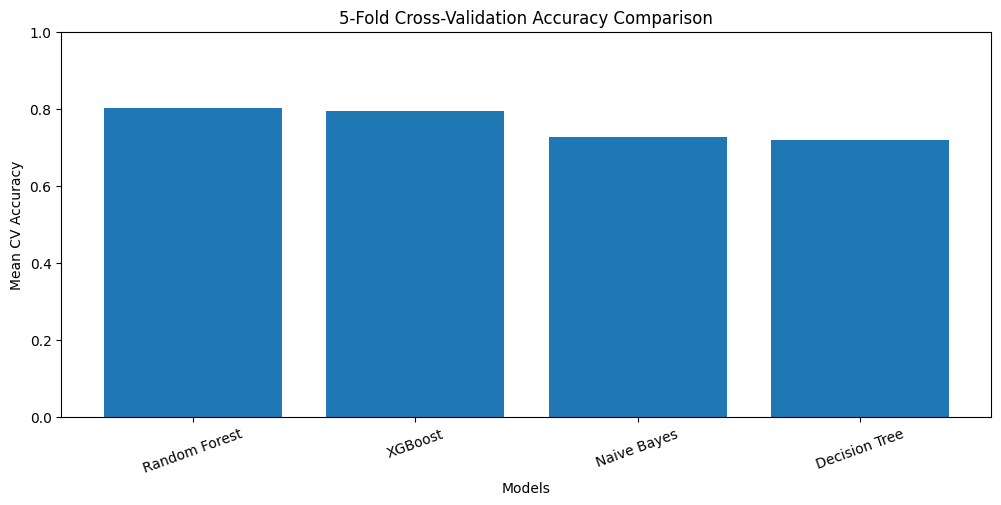

In [22]:
# Cùng thứ tự với bảng: từ mô hình tốt nhất đến thấp nhất
names = cv_table["Mô hình"].tolist()
means = [float(cv_table.loc[cv_table["Mô hình"] == n, "Mean CV Accuracy"].iloc[0]) for n in names]

plt.figure(figsize=(12, 5))
plt.bar(names, means)
plt.title("5-Fold Cross-Validation Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Mean CV Accuracy")
plt.ylim(0, 1)
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.xticks(rotation=20)

plt.show()

- Vẽ cây quyết định

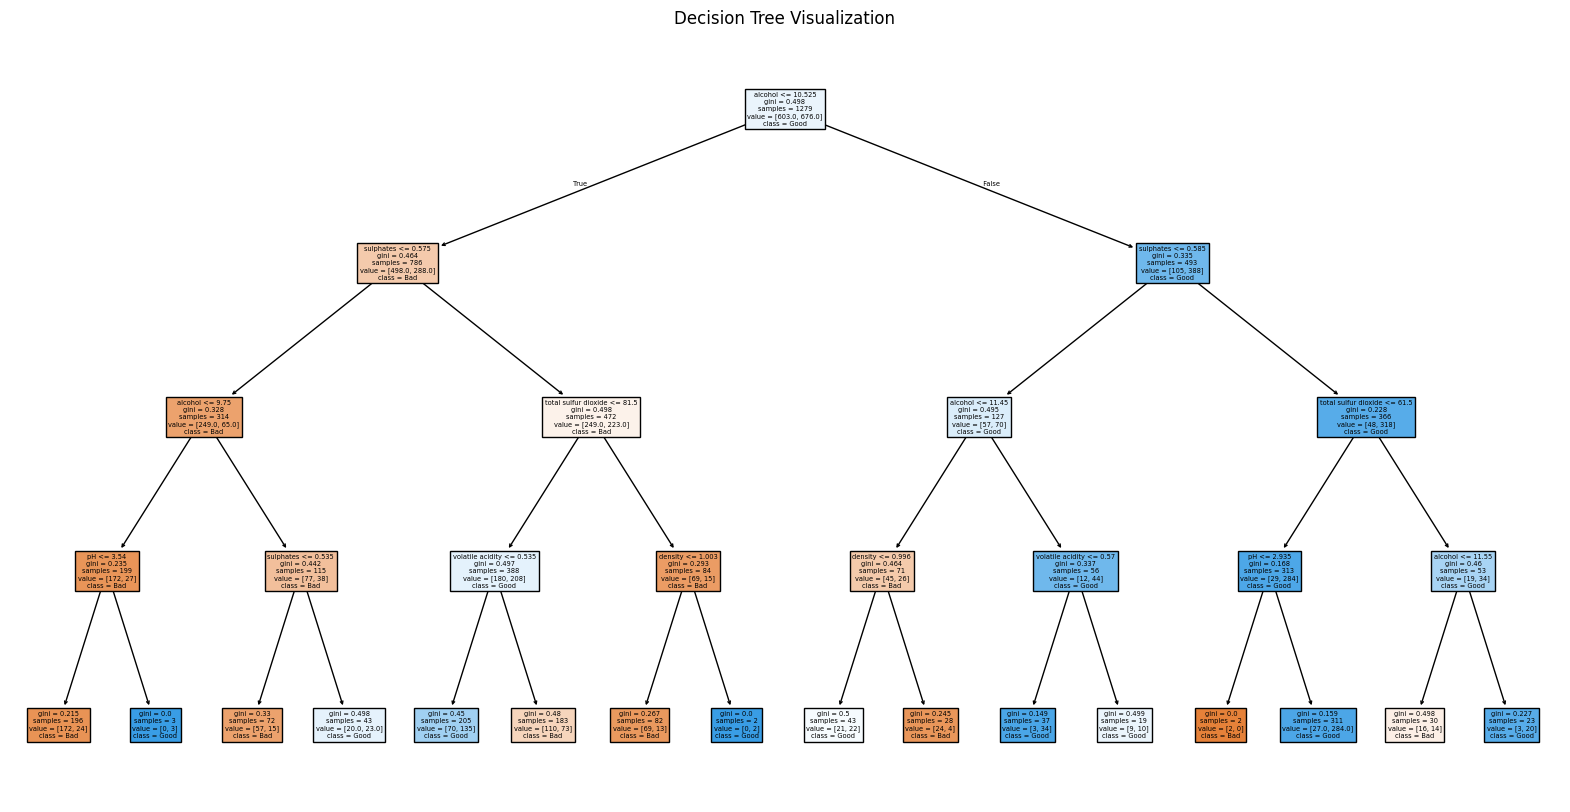

In [24]:
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=["Bad", "Good"], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

**Câu 6: Vẽ biểu đồ độ quan trọng thuộc tính. So sánh giữa: Decision Tree, Random Forest, XGBoost**

In [40]:
feature_names = X.columns


def plot_importance(model, title):
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1]
    sorted_features = [feature_names[i] for i in idx]
    sorted_importances = importances[idx]
    y_labels = list(sorted_features[::-1])
    y_values = sorted_importances[::-1]
    n = len(y_values)
    cmap = plt.get_cmap("Blues")
    colors = [cmap(0.38 + 0.55 * (i / max(n - 1, 1))) for i in range(n)]

    fig, ax = plt.subplots(figsize=(11, 6.5), facecolor="white", dpi=100)
    ax.set_facecolor("white")
    ax.barh(
        y_labels,
        y_values,
        color=colors,
        height=0.72,
        edgecolor="white",
        linewidth=0.6,
    )
    ax.set_title(title, fontsize=13, fontweight="medium", pad=12)
    ax.set_xlabel("Importance", fontsize=11)
    m = float(np.max(y_values))
    x_right = min(1.0, m + 0.08)
    x_right = max(0.15, x_right)
    ax.set_xlim(0, x_right)
    xt = np.arange(0, x_right + 0.02, 0.1)
    xt = xt[xt <= x_right + 1e-6]
    ax.set_xticks(np.round(xt, 1))
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=9)
    for s in ax.spines.values():
        s.set_color("#2d2d2d")
    fig.tight_layout()
    plt.show()

- Decision Tree

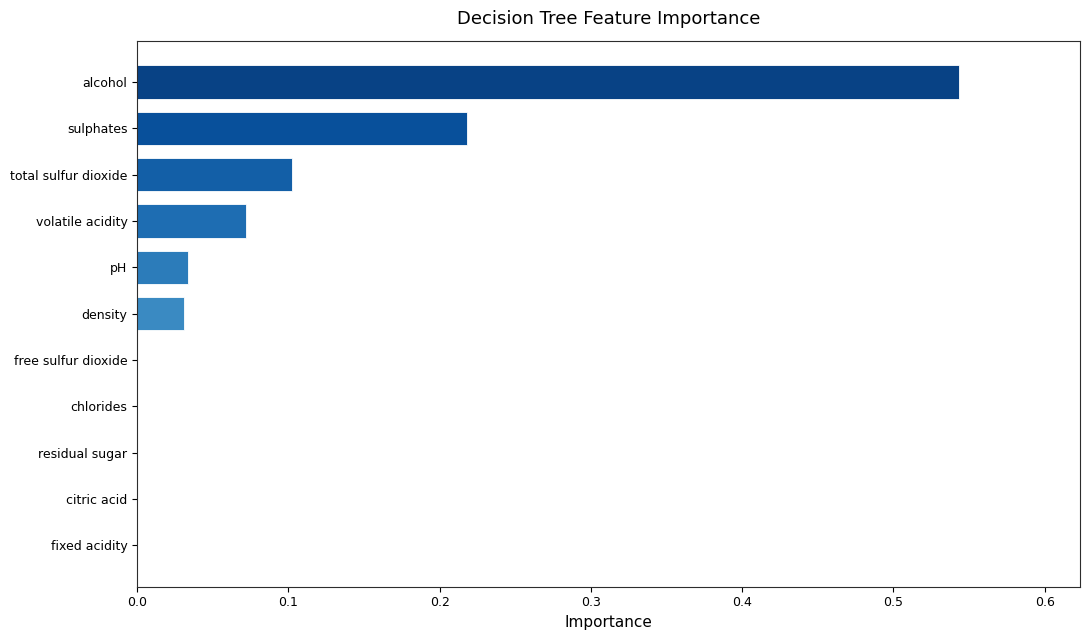

In [42]:
plot_importance(dt, "Decision Tree Feature Importance")

- Random Forest

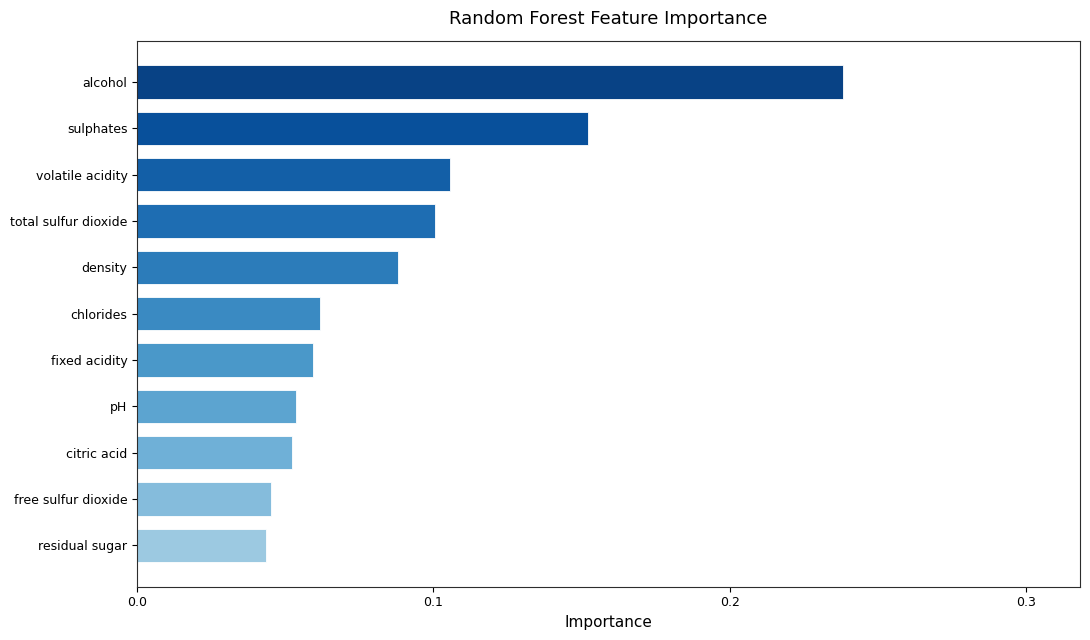

In [43]:
plot_importance(rf, "Random Forest Feature Importance")

- XGBoost

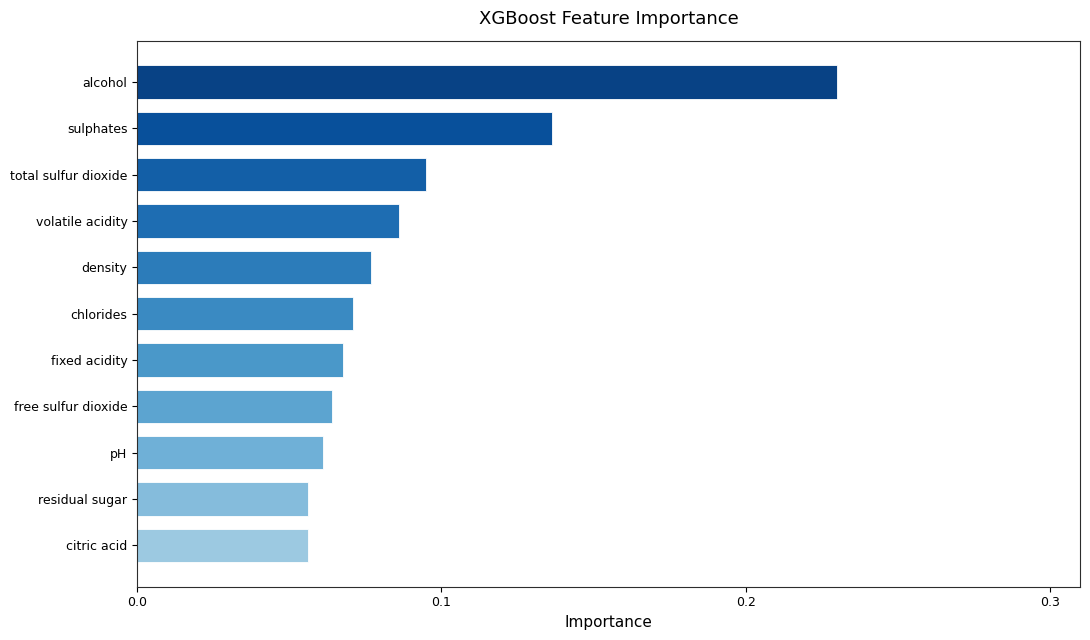

In [44]:
plot_importance(xgb, "XGBoost Feature Importance")

## Bài tập 3:

Câu 1: Nhập dữ liệu đầu vào và tiến hành tiền xử lý xóa các dòng dữ liệu trống, sửa tên các cột dữ liệu lại như sau để dễ theo dõi: ‘age’, ‘sex’, ‘chest_pain_type’, ‘resting_blood_pressure’, ‘cholesterol’, ‘fasting_blood_sugar’, ‘rest_ecg’, ‘max_heart_rate_achieved’, exercise_induced_angina’, ‘st_depression’, ‘st_slope’, ‘num_major_vessels’, ‘thalassemia’, ‘target’.

In [3]:
from pathlib import Path

In [4]:
heart_path = Path("heart.csv")
heart_df = pd.read_csv(heart_path)
print("Shape ban dau:", heart_df.shape)

Shape ban dau: (303, 14)


In [5]:
# Xóa dòng trống / NA
heart_df = heart_df.dropna().reset_index(drop=True)

In [6]:
# Đổi tên cột theo đề
rename_map = {
    "cp": "chest_pain_type",
    "trestbps": "resting_blood_pressure",
    "fbs": "fasting_blood_sugar",
    "restecg": "rest_ecg",
    "thalach": "max_heart_rate_achieved",
    "exang": "exercise_induced_angina",
    "oldpeak": "st_depression",
    "slope": "st_slope",
    "ca": "num_major_vessels",
    "thal": "thalassemia",
}
heart_df = heart_df.rename(columns=rename_map)

In [9]:
# (tuỳ chọn) xóa dòng trùng lặp
dups = int(heart_df.duplicated().sum())
print("So dong trung lap:", dups)
if dups:
    heart_df = heart_df.drop_duplicates().reset_index(drop=True)

# Sửa tên cột 'chol' thành 'cholesterol' nếu cần
if "chol" in heart_df.columns and "cholesterol" not in heart_df.columns:
    heart_df = heart_df.rename(columns={"chol": "cholesterol"})

expected_cols = [
    "age",
    "sex",
    "chest_pain_type",
    "resting_blood_pressure",
    "cholesterol",
    "fasting_blood_sugar",
    "rest_ecg",
    "max_heart_rate_achieved",
    "exercise_induced_angina",
    "st_depression",
    "st_slope",
    "num_major_vessels",
    "thalassemia",
    "target",
]
missing = [c for c in expected_cols if c not in heart_df.columns]
if missing:
    raise ValueError(f"Thieu cot sau khi doi ten: {missing}. Cot hien co: {list(heart_df.columns)}")

heart_df = heart_df[expected_cols]
print("Shape sau tien xu ly:", heart_df.shape)
heart_df.head()

So dong trung lap: 0
Shape sau tien xu ly: (302, 14)


,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [11]:
# Tách X/y và chia train/test 80/20
X_h = heart_df.drop(["target"], axis=1)
y_h = heart_df["target"].astype(int)
heart_feature_names = list(X_h.columns)

# Thiết lập random_state chung cho toàn notebook nếu chưa có
RANDOM_STATE = 42

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_h,
    y_h,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_h,
)

print("Train shape:", Xh_train.shape, "Test shape:", Xh_test.shape)
print("Target distribution (train):")
print(yh_train.value_counts(normalize=True).sort_index())

Train shape: (241, 13) Test shape: (61, 13)
Target distribution (train):
target
0    0.456432
1    0.543568
Name: proportion, dtype: float64


In [12]:
# Hàm đánh giá chung (Accuracy / Precision / Recall / F1)

def eval_binary(y_true, y_pred, title=None):
    m = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, average="binary", pos_label=1, zero_division=0
        ),
        "Recall": recall_score(y_true, y_pred, average="binary", pos_label=1, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="binary", pos_label=1, zero_division=0),
    }
    if title:
        print(title)
    for k, v in m.items():
        print(f"{k}: {v:.4f}")
    return m

Câu 2: Decision Tree (Gini)

In [13]:
heart_dt = Pipeline(
    [
        (
            "clf",
            DecisionTreeClassifier(
                criterion="gini", max_depth=4, random_state=RANDOM_STATE
            ),
        )
    ]
)
heart_dt.fit(Xh_train, yh_train)

y_pred_dt_h = heart_dt.predict(Xh_test)
eval_binary(yh_test, y_pred_dt_h, title="Decision Tree (Gini)")

Decision Tree (Gini)
Accuracy: 0.8033
Precision: 0.7442
Recall: 0.9697
F1-score: 0.8421


{'Accuracy': 0.8032786885245902,
 'Precision': 0.7441860465116279,
 'Recall': 0.9696969696969697,
 'F1-score': 0.8421052631578947}

Câu 3: Gaussian Naive Bayes (+ StandardScaler)

In [14]:
heart_nb = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", GaussianNB()),
    ]
)
heart_nb.fit(Xh_train, yh_train)

y_pred_nb_h = heart_nb.predict(Xh_test)
eval_binary(yh_test, y_pred_nb_h, title="Naive Bayes (StandardScaler + GaussianNB)")

Naive Bayes (StandardScaler + GaussianNB)
Accuracy: 0.8197
Precision: 0.7895
Recall: 0.9091
F1-score: 0.8451


{'Accuracy': 0.819672131147541,
 'Precision': 0.7894736842105263,
 'Recall': 0.9090909090909091,
 'F1-score': 0.8450704225352113}

Câu 4: Random Forest

In [15]:
heart_rf = Pipeline(
    [
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200, max_depth=8, random_state=RANDOM_STATE
            ),
        )
    ]
)
heart_rf.fit(Xh_train, yh_train)

y_pred_rf_h = heart_rf.predict(Xh_test)
eval_binary(yh_test, y_pred_rf_h, title="Random Forest")

Random Forest
Accuracy: 0.7869
Precision: 0.7500
Recall: 0.9091
F1-score: 0.8219


{'Accuracy': 0.7868852459016393,
 'Precision': 0.75,
 'Recall': 0.9090909090909091,
 'F1-score': 0.821917808219178}

Câu 5: XGBoost (+ đánh giá trên test)

In [16]:
heart_xgb = Pipeline(
    [
        (
            "clf",
            XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        )
    ]
)
heart_xgb.fit(Xh_train, yh_train)

y_pred_xgb_h = heart_xgb.predict(Xh_test)
eval_binary(yh_test, y_pred_xgb_h, title="XGBoost")

XGBoost
Accuracy: 0.7869
Precision: 0.7632
Recall: 0.8788
F1-score: 0.8169


{'Accuracy': 0.7868852459016393,
 'Precision': 0.7631578947368421,
 'Recall': 0.8787878787878788,
 'F1-score': 0.8169014084507042}

**So sánh nhanh:** mô hình nào tốt hơn sẽ dựa trên Accuracy/F1 (và Recall nếu ưu tiên phát hiện bệnh = lớp 1).

In [17]:
# K-Fold Cross Validation (k=5) cho các mô hình
heart_models = {
    "Decision Tree": heart_dt,
    "Naive Bayes": heart_nb,
    "Random Forest": heart_rf,
    "XGBoost": heart_xgb,
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in heart_models.items():
    scores = cross_val_score(model, X_h, y_h, cv=kf, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")

Decision Tree: Mean = 0.7685, Std = 0.0606
Naive Bayes: Mean = 0.8143, Std = 0.0649
Random Forest: Mean = 0.8311, Std = 0.0529
XGBoost: Mean = 0.8177, Std = 0.0464


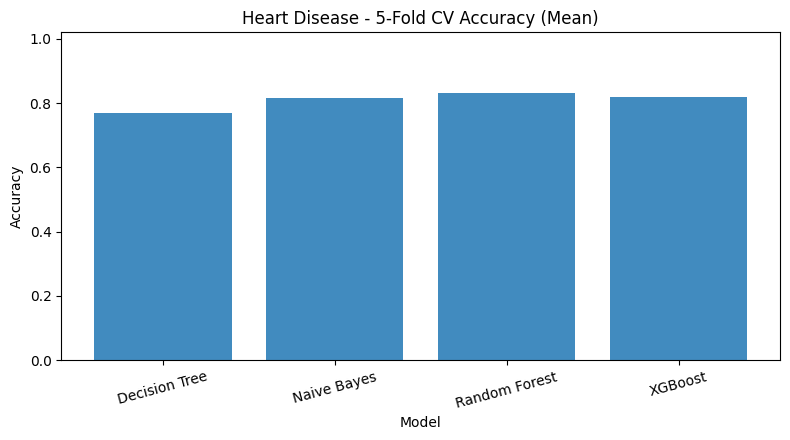

In [ ]:
# Vẽ biểu đồ so sánh accuracy trung bình từ K-Fold
names = list(cv_results.keys())
means = [float(cv_results[n].mean()) for n in names]

plt.figure(figsize=(8, 4.5))
plt.bar(names, means, alpha=0.85)
plt.title("Heart Disease - 5-Fold CV Accuracy (Mean)")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.02)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

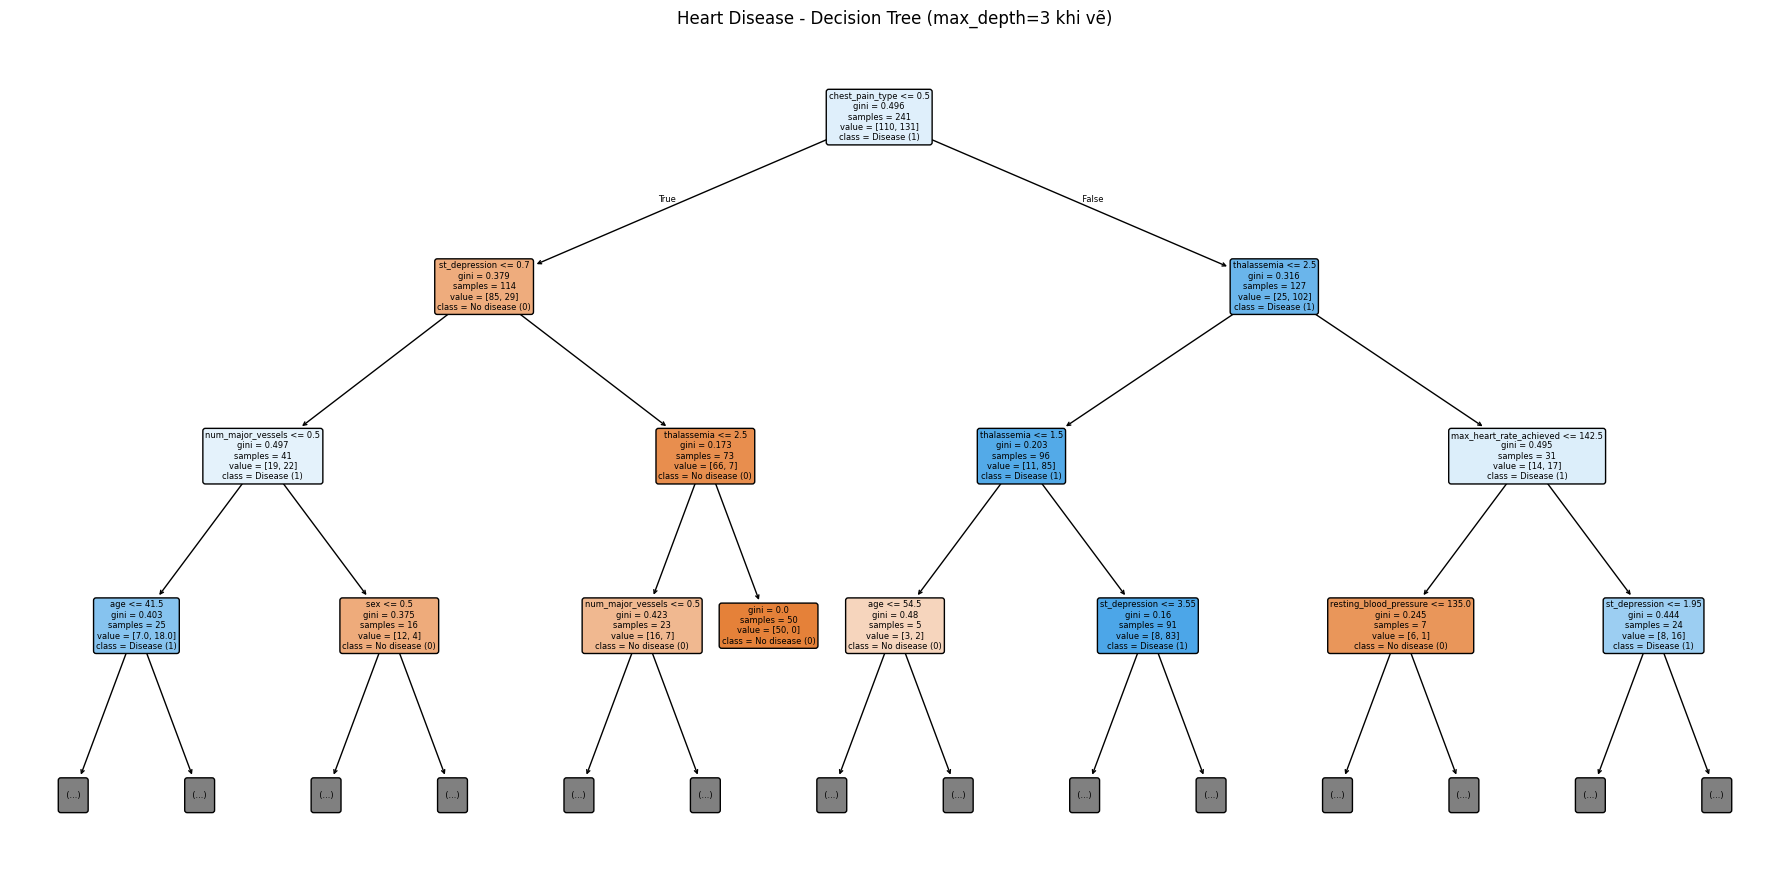

In [20]:
# Vẽ cây quyết định (minh hoạ) - giới hạn độ sâu khi vẽ cho dễ nhìn
# Lưu ý: estimator thật nằm trong pipeline -> lấy bằng named_steps

dt_est = heart_dt.named_steps["clf"]

fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(
    dt_est,
    feature_names=heart_feature_names,
    class_names=["No disease (0)", "Disease (1)"],
    filled=True,
    rounded=True,
    fontsize=6,
    max_depth=3,
    ax=ax,
)
ax.set_title("Heart Disease - Decision Tree (max_depth=3 khi vẽ)")
plt.tight_layout()
plt.show()

Câu 6: Độ quan trọng thuộc tính (feature_importances_) cho DT / RF / XGB

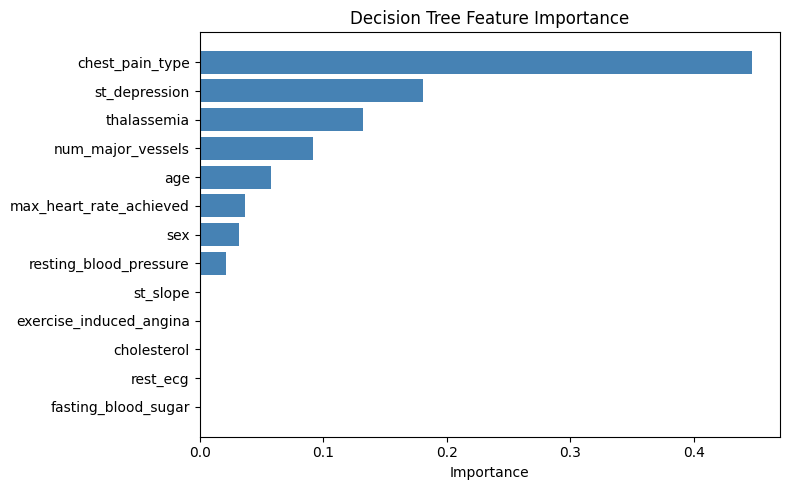

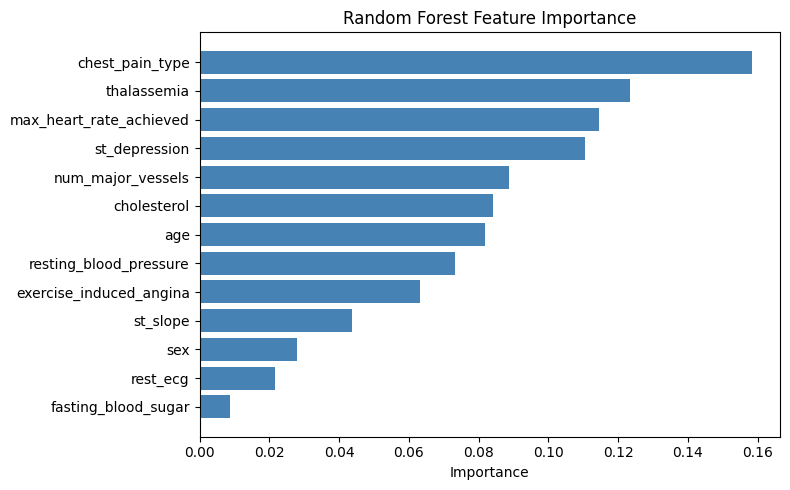

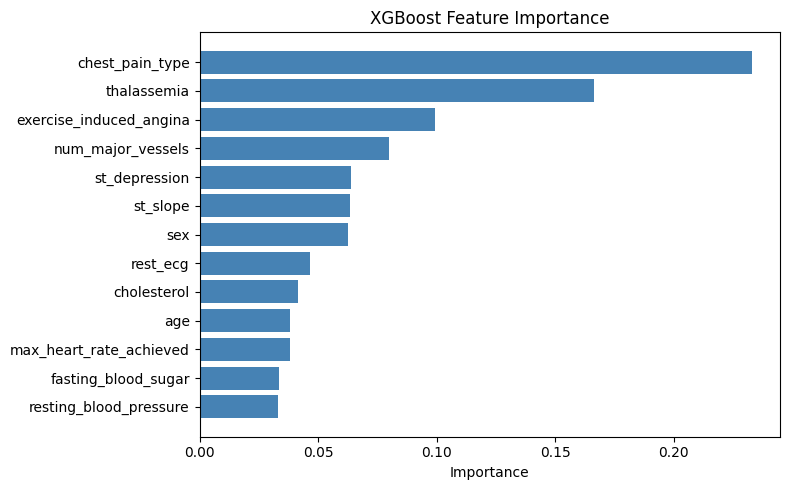

In [21]:
def bar_importance(imp, title, feature_names):
    order = np.argsort(imp)[::-1]
    sorted_features = [feature_names[i] for i in order]
    sorted_importances = imp[order]

    plt.figure(figsize=(8, 5))
    plt.barh(sorted_features[::-1], sorted_importances[::-1], color="steelblue")
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

# DT
bar_importance(dt_est.feature_importances_, "Decision Tree Feature Importance", heart_feature_names)

# RF
rf_est = heart_rf.named_steps["clf"]
bar_importance(rf_est.feature_importances_, "Random Forest Feature Importance", heart_feature_names)

# XGB
xgb_est = heart_xgb.named_steps["clf"]
bar_importance(xgb_est.feature_importances_, "XGBoost Feature Importance", heart_feature_names)